# Linear elasticity: material robustness

2D cantilevered rectangular beam under gravity. Fixed on the left face; traction-free on the right, top, and bottom.

Hellinger–Reissner mixed formulation with the Johnson–Mercier element (symmetric $P_1$ stress in $H(\operatorname{div})$, $P_0$ displacement). The zero-displacement BC on the clamped face is natural (prescribed displacement enters the RHS and vanishes since $g=0$); zero traction on the free faces is the essential BC on the stress space.

In [162]:
try:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh" -O "/tmp/firedrake-install.sh"
    !bash "/tmp/firedrake-install.sh"
    from firedrake import *  # noqa: F401
except:
    from firedrake import *  # noqa: F401

--2026-05-28 02:39:12--  https://fem-on-colab.github.io/releases/firedrake-install-development-real.sh
Resolving fem-on-colab.github.io (fem-on-colab.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to fem-on-colab.github.io (fem-on-colab.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4775 (4.7K) [application/x-sh]
Saving to: ‘/tmp/firedrake-install.sh’

/tmp/firedrake-inst 100%[===================>]   4.66K  --.-KB/s    in 0s      

2026-05-28 02:39:12 (47.5 MB/s) - ‘/tmp/firedrake-install.sh’ saved [4775/4775]

+ INSTALL_PREFIX=/usr/local
++ echo /usr/local
++ awk -F/ '{print NF-1}'
+ INSTALL_PREFIX_DEPTH=2
+ PROJECT_NAME=fem-on-colab
+ SHARE_PREFIX=/usr/local/share/fem-on-colab
+ FIREDRAKE_INSTALLED=/usr/local/share/fem-on-colab/firedrake.installed
+ [[ ! -f /usr/local/share/fem-on-colab/firedrake.installed ]]
+ set +x
























#########################################################

In [163]:
# Rectangular beam: length x height
length, height = 5.0, 1.0
mesh = RectangleMesh(20, 20, length, height)
n = FacetNormal(mesh)
x, y = SpatialCoordinate(mesh)
d = 2  # spatial dimension

# Material parameters
nu = Constant(0.3)
mu = 1 / (2*(1 + nu))
lmbda = nu / ((1 + nu)*(1 - 2*nu))

In [164]:
# Johnson-Mercier pair
JM = FunctionSpace(mesh, "JM", 1)
DG = VectorFunctionSpace(mesh, "DG", 0, variant="alfeld")
W = JM * DG

# Functions
sigma, u_0 = TrialFunctions(W)
tau,   v   = TestFunctions(W)

# Lifting
phi = - cos(pi * x / length)
phi_prime = sin(pi * x / length) * pi / length
# phi_prime = diff(phi, x)
u_BC = 0.5 * as_vector([(y - height/2) * phi_prime, phi])

# Compliance tensor
def A(s):
    return (1/(2*mu))*s - (lmbda/(2*mu*(2*mu + d*lmbda)))*tr(s)*Identity(d)

# Form
a = (inner(A(sigma), tau) + inner(u_0, div(tau)) + inner(div(sigma), v)) * dx
L = inner(sym(grad(u_BC)), tau) * dx

# Boundary conditions
bcs = [
    DirichletBC(W.sub(0), 0, 3),
    DirichletBC(W.sub(0), 0, 4)
]

# Solve
w = Function(W)
solve(a == L, w, bcs=bcs)

# Output
sigma, u_0 = w.subfunctions
u = Function(DG).project(u_BC + u_0)
u_cg = project(u, VectorFunctionSpace(mesh, "CG", 1))
sig_vm = sqrt(sigma[0, 0]**2 - sigma[0, 0]*sigma[1, 1] + sigma[1, 1]**2 + 3*sigma[0, 1]**2)
sig_vm_dg = Function(FunctionSpace(mesh, "DG", 0)).project(sig_vm)
sig_vm_cg = Function(FunctionSpace(mesh, "CG", 1)).project(sig_vm)

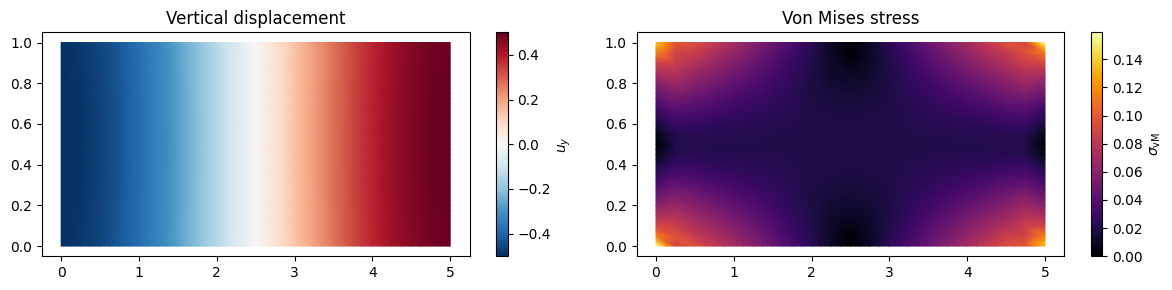

In [165]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Vertical displacement
c0 = tripcolor(u_cg.sub(1), axes=axes[0], cmap="RdBu_r")
plt.colorbar(c0, ax=axes[0], label=r"$u_y$")
# axes[0].set_aspect("equal")
axes[0].set_title("Vertical displacement")

# Von Mises stress
sig_vm_dg = Function(FunctionSpace(mesh, "DG", 0), name="Von Mises stress").project(sig_vm)
# sig_vm.interpolate(sqrt(sigma[0, 0]**2 - sigma[0, 0]*sigma[1, 1] + sigma[1, 1]**2 + 3*sigma[0, 1]**2))
c1 = tripcolor(sig_vm_cg, axes=axes[1], cmap="inferno")
plt.colorbar(c1, ax=axes[1], label=r"$\sigma_\mathrm{vM}$")
# axes[1].set_aspect("equal")
axes[1].set_title("Von Mises stress")

plt.tight_layout()
plt.show()

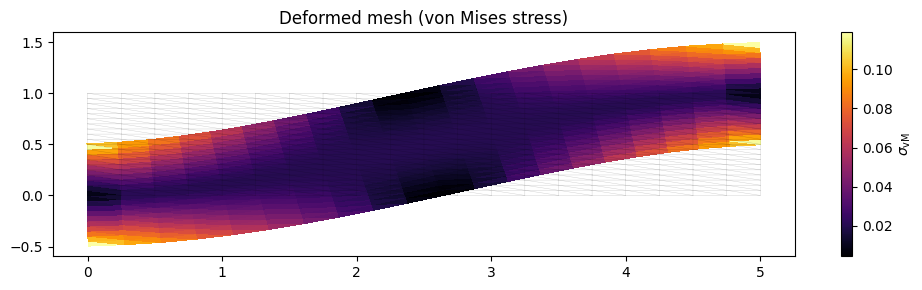

In [166]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

coords = mesh.coordinates.dat.data_ro             # (n_verts, 2)
cells  = mesh.coordinates.cell_node_map().values  # (n_cells, 3)
disp   = u_cg.dat.data_ro                         # (n_verts, 2)

triang_ref = mtri.Triangulation(coords[:, 0], coords[:, 1], cells)
triang_def = mtri.Triangulation(
    coords[:, 0] + disp[:, 0],
    coords[:, 1] + disp[:, 1],
    cells,
)

fig, ax = plt.subplots(figsize=(10, 3))
tc = ax.tripcolor(triang_def, facecolors=sig_vm_dg.dat.data_ro, cmap="inferno")
plt.colorbar(tc, ax=ax, label=r"$\sigma_\mathrm{vM}$")
ax.triplot(triang_ref, color="k", linewidth=0.3, alpha=0.2)
# ax.set_aspect("equal")
ax.set_title(f"Deformed mesh (von Mises stress)")
plt.tight_layout()
plt.show()